In [2]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [3]:
scan_modelgen = h5py.File("../data/version-9/SP_MSSM7atQ_random_modelgen.hdf5", "r")["MSSM"]
scan_gambit = h5py.File("tests/sanity_check/samples/MSSM7atQ.hdf5", "r")["MSSM"]

In [4]:
def parameter_lookup(parameter: str, conversion_table: str = "conversion_table.txt") -> str:
    """
    For any givern parameter look up its counterpart (GAMBIT <-> MODELGEN) in the conversion table.
    If the parameter is not found ask the user for the counterpart and add it to the table.

    returns: str (gambit-parameter;modelgen-parameter)
    """
    parameter_type = "gambit" if len(parameter.split(" ")) > 1 else "modelgen"

    def add_conversion_entry():
        if parameter_type == "gambit":
            gambit_par = parameter
            modelgen_par = input(f"enter the corresponding MODELGEN parameter name for {parameter}").strip()
        if parameter_type == "modelgen":
            gambit_par = input(f"enter the corresponding GAMBIT parameter name for {parameter}").strip()
            modelgen_par = parameter
        parameter_pair = "\n" + gambit_par + ";" + modelgen_par
        with open(conversion_table, "a") as file:
            file.write(parameter_pair)
        return parameter_pair.strip()

    if not os.path.isfile(conversion_table):
        parameter_pair = add_conversion_entry()
        return parameter_pair

    with open(conversion_table, "r") as file:
        for line in file:
            if parameter in line:
                parameter_pair = line.strip()
                return parameter_pair
            
    parameter_pair = add_conversion_entry()
    return parameter_pair

In [5]:
parameter = "SP_m_chi_10"

In [6]:
def scatter(parameter):
    mask_gambit = scan_gambit[parameter_lookup(parameter).split(";")[0] + "_isvalid"][:] == 1
    gambit_data = scan_gambit[parameter_lookup(parameter).split(";")[0]][mask_gambit]
    mask_modelgen = scan_modelgen[parameter_lookup(parameter).split(";")[1]][:] != -1
    modelgen_data = scan_modelgen[parameter_lookup(parameter).split(";")[1]][mask_modelgen]

    # print("Scan          | VALID/ATTEMPTED")
    # print("-------------------------------------")
    # print(f"GAMBIT random | {np.sum(mask_gambit)}/{len(mask_gambit)}  {(np.sum(mask_gambit)/len(mask_gambit))*100:.2f}%")
    # print(f"MODELGEN      | {np.sum(mask_modelgen)}/{len(mask_modelgen)}  {(np.sum(mask_modelgen)/len(mask_modelgen))*100:.2f}%")

    fig = plt.figure(figsize=(7,5))
    ax = fig.add_subplot(111)

    ax.scatter(gambit_data, modelgen_data, s=10, color="grey", alpha=0.5)
    ax.set_xlabel("GAMBIT")
    ax.set_ylabel("MODELGEN")
    ax.set_title(f"{parameter_lookup(parameter).split(';')[1]}")
    ax.minorticks_on()
    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)

    fig.savefig(f"plots/scatter-{parameter_lookup(parameter).split(';')[1]}.png", dpi=1000)

    plt.show()
    plt.close()
    



In [7]:
def plot_all(conversion_table_path: str):
    with open(conversion_table_path, 'r') as conversion_table:
        parameter_list = conversion_table.readlines()
    
    parameter_list = [par.strip().split(';')[-1] for par in parameter_list]
    for par in parameter_list: 
        try: scatter(par)
        except: print(f"Could not plot parameter {par}")

# plot_all("conversion_table.txt")

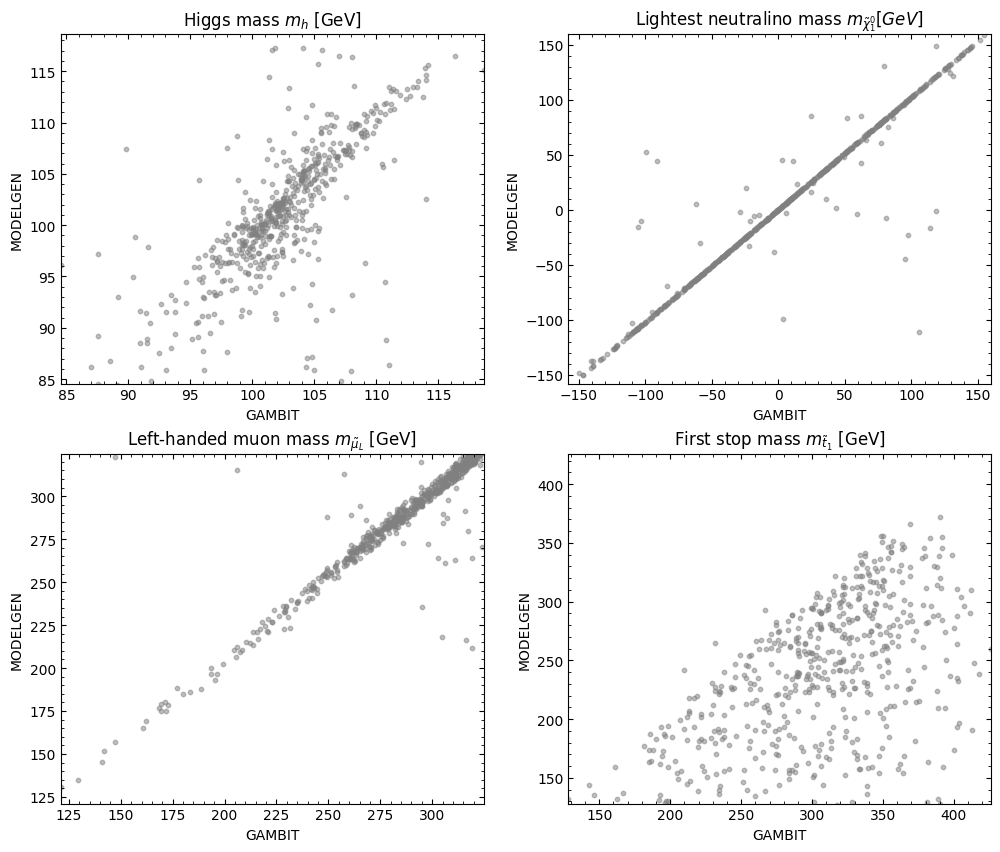

In [8]:
parameter_list = ["SP_m_h", "SP_m_chi_10", "SP_m_mu_L", "SP_m_t_1"]

fig = plt.figure(figsize=(12, 10))
ax1 = fig.add_subplot(221)
ax2 = fig.add_subplot(222)
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224)

ax_list = [ax1, ax2, ax3, ax4]

def populate_ax(parameter, ax):
    mask_gambit = scan_gambit[parameter_lookup(parameter).split(";")[0] + "_isvalid"][:] == 1
    gambit_data = scan_gambit[parameter_lookup(parameter).split(";")[0]][mask_gambit]
    mask_modelgen = scan_modelgen[parameter_lookup(parameter).split(";")[1]][:] != -1
    modelgen_data = scan_modelgen[parameter_lookup(parameter).split(";")[1]][mask_modelgen]


    ax.scatter(gambit_data, modelgen_data, s=10, color="grey", alpha=0.5)
    ax.set_xlim(np.min(gambit_data), np.max(gambit_data))
    ax.set_ylim(np.min(gambit_data), np.max(gambit_data))
    ax.set_xlabel("GAMBIT")
    ax.set_ylabel("MODELGEN")
    ax.minorticks_on()
    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)

for idx, par in enumerate(parameter_list):
    populate_ax(par, ax_list[idx])

ax1.set_title("Higgs mass $m_h$ [GeV]")
ax2.set_title("Lightest neutralino mass $m_{\\tilde{\\chi}_1^0} [GeV]$")
ax3.set_title("Left-handed muon mass $m_{\\tilde{\\mu}_L}$ [GeV]")
ax4.set_title("First stop mass $m_{\\tilde{t}_1}$ [GeV]")

fig.savefig(f"plots/thesis_plots/sanity_check.png", dpi=1000)

plt.show()

In [9]:


GAMBIT_RANDOM = "FS_MSSM7atQ_random_gambit.hdf5"
GAMBIT_DIVER = "FS_MSSM7atQ_diver_gm2_gambit.hdf5"
# GAMBIT_DIVER = "FS_MSSM7atQ_diver_relicd_gambit.hdf5"
MODELGEN = "SP_MSSM7atQ_random_modelgen.hdf5"
VERSION = 9

def open_scan(file_name: str, version: str = VERSION) -> h5py.File:
    """open a scan file and return the h5py File object"""
    file_path = f"../data/version-{version}/{file_name}"

    return h5py.File(file_path, "r")["MSSM"]

scan_modelgen = open_scan(MODELGEN)
scan_gambit_random = open_scan(GAMBIT_RANDOM)
scan_gambit_diver = open_scan(GAMBIT_DIVER)

In [10]:
paramter_pair = parameter_lookup("SP_m_W").split(";")
data_gr = scan_gambit_random[paramter_pair[0]][scan_gambit_random[paramter_pair[0] + "_isvalid"][:] == 1]
data_gd = scan_gambit_diver[paramter_pair[0]][scan_gambit_diver[paramter_pair[0] + "_isvalid"][:] == 1]
data_mg = scan_modelgen[paramter_pair[1]][scan_modelgen[paramter_pair[1]][:] != -1]